In [26]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
words[:8]

32033
15


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [2]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0 # add a special "end of word" character
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [3]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

... ----> y
..y ----> u
.yu ----> h
yuh ----> e
uhe ----> n
hen ----> g
eng ----> .
... ----> d
..d ----> i
.di ----> o


In [6]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


In [7]:
torch.manual_seed(42); # seed rng for reproducibility

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), 
]
# layers = [
#     Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size, bias = False), BatchNorm1d(vocab_size),
# ]

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [9]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    # break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.3088
  10000/200000: 2.2272
  20000/200000: 2.4214
  30000/200000: 2.2528
  40000/200000: 1.9795
  50000/200000: 2.3358
  60000/200000: 2.2202
  70000/200000: 2.5409
  80000/200000: 1.8563
  90000/200000: 2.2147
 100000/200000: 2.1531
 110000/200000: 2.1085
 120000/200000: 2.2899
 130000/200000: 2.1656
 140000/200000: 2.0296
 150000/200000: 2.2017
 160000/200000: 1.8975
 170000/200000: 2.3092
 180000/200000: 1.9847
 190000/200000: 2.2783


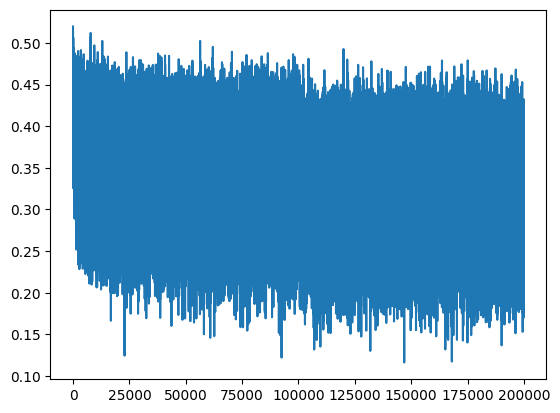

In [10]:
plt.plot(lossi)

In [11]:
# put layers into eval mode (needed for batchnorm especoially)
for layer in layers:
    layer.training = False

In [12]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0633294582366943
val 2.1048269271850586


In [13]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

ivalee.
they.
aashha.
zaristigan.
ella.
kel.
cott.
nehett.
lie.
heison.
avah.
malakaria.
gretu.
bel.
yal.
shelston.
corynezaysen.
stafariceleem.
jaxtophon.
mariyah.


In [14]:
torch.arange(10).view(2,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [15]:
torch.arange(10).view(-1,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [16]:
torch.tensor(lossi).view(-1,10000).mean(1)

tensor([0.3684, 0.3491, 0.3447, 0.3413, 0.3394, 0.3366, 0.3371, 0.3358, 0.3349,
        0.3339, 0.3210, 0.3199, 0.3200, 0.3197, 0.3192, 0.3186, 0.3191, 0.3193,
        0.3183, 0.3182])

In [17]:
torch.tensor(lossi).view(-1,10000).mean(1).shape

torch.Size([20])

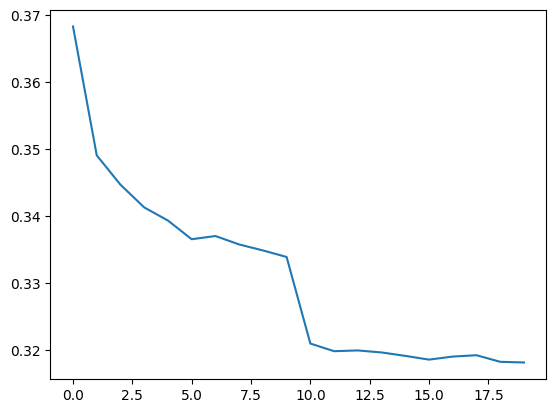

In [18]:
plt.plot(torch.tensor(lossi).view(-1,10000).mean(1))

In [29]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) 
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []

In [31]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
# g = torch.Generator().manual_seed(2147483647) # for reproducibility
# C = torch.randn((vocab_size, n_embd), generator=g)
model = [Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),]

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [33]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    # emb = C[Xb]  # embed the characters into vectors
    # x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.2990


In [34]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) 
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layers and streth them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [35]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
# g = torch.Generator().manual_seed(2147483647) # for reproducibility
# C = torch.randn((vocab_size, n_embd), generator=g)
model = Sequential([Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [36]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.4517


In [39]:
for layer in model.layers:
    layer.training = False

In [40]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 3.393707275390625
val 3.4000766277313232


In [41]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

xdudfhemiglnzlklerk.
bfbpxaihlmxeqmlbdvmzwzyjchtpqjxhpsqqjwruiipndkse.
bzcfwfpakeens.
jhlhyhfmmjldtjysdbglppprqnmtfvzenakfts.
.
mflqnmidzmwggzeveyuqhnarslzelgsd.
jkcctbjnpecjonjikbcjjrhyotxzeffwbhdzjometkfpdujemqovtjswzkfydy.
voktkmyfnmulzhippebawvmjzwqgmutttplesngmhefbzzxrgenkgfmjqcxrggqaqe.
gurdkakthlpwzzv.
prcfnekiitmtdvviccnmfqwvaxgzpelippaqddj.
fiiguwahwol.
wwmhprhihzffvzdijkagnwmodhkqdrtaan.
gzwaixzja.
nawhpxvndcdwnogpvoqfapnv.
dwqlrk.
gyad.
faoaprbpwyads.
cpxydiorv.
ukkgpiktg.
.


In [42]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182778, 8]) torch.Size([182778])
torch.Size([22633, 8]) torch.Size([22633])
torch.Size([22735, 8]) torch.Size([22735])


In [43]:
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

........ ----> e
.......e ----> m
......em ----> m
.....emm ----> a
....emma ----> .
........ ----> o
.......o ----> l
......ol ----> i
.....oli ----> v
....oliv ----> i


In [44]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) 
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layers and streth them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [45]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
# g = torch.Generator().manual_seed(2147483647) # for reproducibility
# C = torch.randn((vocab_size, n_embd), generator=g)
model = Sequential([Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

22097


In [48]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.2152
  10000/200000: 2.1269
  20000/200000: 1.7590
  30000/200000: 2.0021
  40000/200000: 1.8483
  50000/200000: 1.5384
  60000/200000: 1.9159
  70000/200000: 2.4219
  80000/200000: 1.7714
  90000/200000: 1.8704
 100000/200000: 1.9310
 110000/200000: 2.0270
 120000/200000: 1.6645
 130000/200000: 2.1937
 140000/200000: 1.9655
 150000/200000: 2.0596
 160000/200000: 1.7100
 170000/200000: 1.9287
 180000/200000: 1.7600
 190000/200000: 2.0846


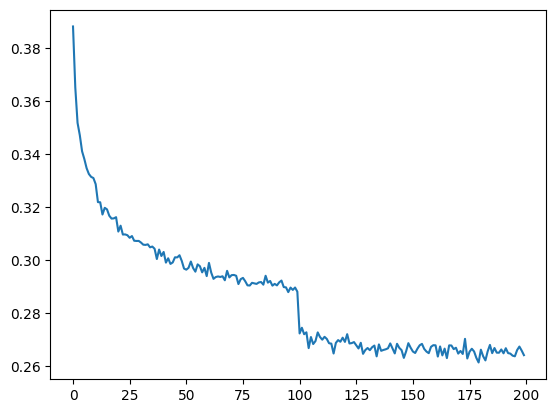

In [50]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [51]:
for layer in model.layers:
    layer.training = False


@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 1.8563144207000732
val 2.290882110595703


In [52]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

anari.
jourza.
kinnow.
madilyny.
muholi.
navia.
camperli.
briag.
yianni.
daran.
zzavira.
keyaan.
marion.
tana.
denikomen.
elyse.
alaurien.
lindgar.
fasyn.
caralah.


In [53]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # a batch of 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]  
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  9],
        [ 0,  0,  0,  0,  0,  0,  0,  3],
        [ 0,  0,  0,  0,  0,  1, 19,  5],
        [ 0,  0,  0,  0,  0,  0,  1, 20]])

In [54]:
model.layers[0].out.shape # output of the embedding layer is (batch_size, block_size, n_embd)

torch.Size([4, 8, 10])

In [55]:
model.layers[1].out.shape # output of the flatten layer is (batch_size, block_size * n_embd)

torch.Size([4, 80])

In [56]:
model.layers[2].out.shape # output of the first linear layer is (batch_size, n_hidden)

torch.Size([4, 200])

In [58]:
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape 

torch.Size([4, 4, 200])

In [61]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [62]:
list(range(10))[::2]

[0, 2, 4, 6, 8]

In [63]:
e = torch.randn(4, 8, 10)
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [64]:
(e.view(4, 4, 20) == explicit).all()

tensor(True)

In [73]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) 
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
        
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layers and streth them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [69]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential([Embedding(vocab_size, n_embd), 
    FlattenConsecutive(block_size),
    Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

22097


In [70]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # a batch of 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]  
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 13,  1, 14,  1, 12],
        [ 0,  0,  0,  3,  1, 13,  5, 18]])

In [71]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [76]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential([Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

170897


In [77]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # a batch of 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]  
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  5, 20],
        [ 0,  0,  0,  0,  0, 10,  1, 26],
        [ 0,  0,  0,  0,  4, 21, 20,  3],
        [ 0,  0, 11,  1, 18,  9, 13,  1]])

In [78]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [79]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

model = Sequential([Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

22397


In [80]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.5472
  10000/200000: 2.1354
  20000/200000: 1.6337
  30000/200000: 1.6207
  40000/200000: 1.9600
  50000/200000: 2.4151
  60000/200000: 1.9721
  70000/200000: 2.0016
  80000/200000: 1.9052
  90000/200000: 2.0014
 100000/200000: 1.9372
 110000/200000: 2.2890
 120000/200000: 2.1894
 130000/200000: 1.8856
 140000/200000: 1.9383
 150000/200000: 1.8585
 160000/200000: 2.1680
 170000/200000: 2.0004
 180000/200000: 2.3869
 190000/200000: 1.7625


In [83]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 1.9025455713272095
val 2.257943868637085


In [84]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (22633, 8, 10)
FlattenConsecutive : (22633, 4, 20)
Linear : (22633, 4, 68)
BatchNorm1d : (22633, 4, 68)
Tanh : (22633, 4, 68)
FlattenConsecutive : (22633, 2, 136)
Linear : (22633, 2, 68)
BatchNorm1d : (22633, 2, 68)
Tanh : (22633, 2, 68)
FlattenConsecutive : (22633, 136)
Linear : (22633, 68)
BatchNorm1d : (22633, 68)
Tanh : (22633, 68)
Linear : (22633, 27)


In [85]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) # 1, 4, 68
evar = e.var(0, keepdim=True) # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [86]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [87]:
e = torch.randn(32, 4, 68)
emean = e.mean((0,1), keepdim=True) # 1, 4, 68
evar = e.var((0,1), keepdim=True) # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [88]:
# Near copy paste of the layers 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) 
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
        
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layers and streth them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [93]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

model = Sequential([Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

22397


In [99]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.2953
  10000/200000: 2.0233
  20000/200000: 1.9020
  30000/200000: 1.5171
  40000/200000: 2.0375
  50000/200000: 1.8239
  60000/200000: 2.3739
  70000/200000: 1.6673
  80000/200000: 2.0774
  90000/200000: 2.2010
 100000/200000: 2.0797
 110000/200000: 1.9238
 120000/200000: 1.8304
 130000/200000: 2.0083
 140000/200000: 1.4661
 150000/200000: 1.7016
 160000/200000: 1.3595
 170000/200000: 2.1295
 180000/200000: 1.7763
 190000/200000: 1.8245


In [100]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [101]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [102]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 1.8509485721588135
val 2.2862446308135986


In [103]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size),])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident
            
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

76579


In [104]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.2909
  10000/200000: 2.2413
  20000/200000: 1.7798
  30000/200000: 1.8575
  40000/200000: 2.1515
  50000/200000: 2.1305
  60000/200000: 1.9984
  70000/200000: 1.7858
  80000/200000: 2.2722
  90000/200000: 1.8276
 100000/200000: 1.9549
 110000/200000: 2.2434
 120000/200000: 1.8729
 130000/200000: 1.5631
 140000/200000: 1.7227
 150000/200000: 1.5933
 160000/200000: 2.0801
 170000/200000: 2.0852
 180000/200000: 1.6074
 190000/200000: 1.7737


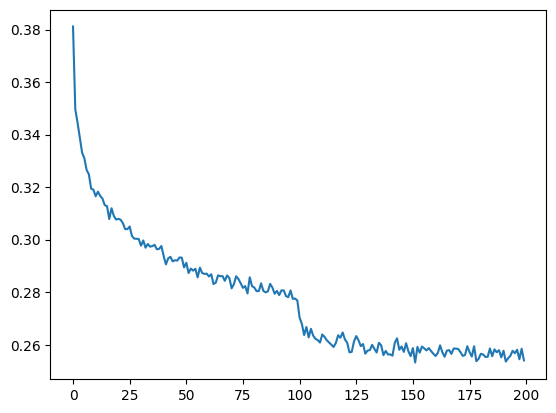

In [105]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [106]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7741081714630127
val 2.2239136695861816


In [107]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

dearosh.
nova.
shita.
braxtyn.
nomari.
jaylani.
elliya.
mikelle.
resaad.
jessathan.
gamalin.
aashl.
demyys.
shivha.
jenaiyah.
ishika.
aunsan.
jaleigh.
oaquel.
creen.


In [108]:
# why convolution?
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

........ ----> e
.......e ----> m
......em ----> m
.....emm ----> a
....emma ----> .
........ ----> o
.......o ----> l
......ol ----> i
.....oli ----> v
....oliv ----> i


In [113]:
# forward a single example
logits = model(Xtr[:7]) 
logits.shape

torch.Size([7, 27])

In [118]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(Xtr.shape[0]):
    logits[i] = model(Xtr[i].unsqueeze(0))
logits.shape

IndexError: index 8 is out of bounds for dimension 0 with size 8

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space